In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Getting Basic Information about the dataset

In [2]:
df = pd.read_csv("dataset/zomato.csv")
df.head(3)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


In [3]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [5]:
len(df)

51717

### Checking null values

In [6]:
df.isna().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

### Keeping only necessary columns

In [7]:
df2 = df[["rate","rest_type", "cuisines", "approx_cost(for two people)", "name", "online_order", "book_table", "votes", "listed_in(type)", "location"]]
df2.head(3)

,rate,rest_type,cuisines,approx_cost(for two people),name,online_order,book_table,votes,listed_in(type),location
0,4.1/5,Casual Dining,"North Indian, Mughlai, Chinese",800,Jalsa,Yes,Yes,775,Buffet,Banashankari
1,4.1/5,Casual Dining,"Chinese, North Indian, Thai",800,Spice Elephant,Yes,No,787,Buffet,Banashankari
2,3.8/5,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,San Churro Cafe,Yes,No,918,Buffet,Banashankari


### Checking null values in the remaining columns

In [8]:
df2.isnull().sum()

rate                           7775
rest_type                       227
cuisines                         45
approx_cost(for two people)     346
name                              0
online_order                      0
book_table                        0
votes                             0
listed_in(type)                   0
location                         21
dtype: int64

In [9]:
df2.shape

(51717, 10)

In [10]:
df2[df2["rate"].isnull()].head()

,rate,rest_type,cuisines,approx_cost(for two people),name,online_order,book_table,votes,listed_in(type),location
84,NaN,Quick Bites,"South Indian, Chinese",100,Chill Out,No,No,0,Delivery,Banashankari
90,NaN,Delivery,"Bakery, Desserts",500,Me And My Cake,No,No,0,Delivery,Banashankari
91,NaN,"Takeaway, Delivery",South Indian,400,Sunsadm,No,No,0,Delivery,Banashankari
92,NaN,Mess,South Indian,200,Annapooraneshwari Mess,No,No,0,Delivery,Banashankari
107,NaN,"Takeaway, Delivery",Beverages,250,Coffee Shopee,No,No,0,Delivery,Banashankari


### Feature Eng (converting rate to numeric for better usability)

In [11]:
df2["rate"] = df2["rate"].str.split("/").str[0].str.strip()
df2["rate"] = pd.to_numeric(df2["rate"], errors="coerce")

In [12]:
df2.head()

,rate,rest_type,cuisines,approx_cost(for two people),name,online_order,book_table,votes,listed_in(type),location
0,4.1,Casual Dining,"North Indian, Mughlai, Chinese",800,Jalsa,Yes,Yes,775,Buffet,Banashankari
1,4.1,Casual Dining,"Chinese, North Indian, Thai",800,Spice Elephant,Yes,No,787,Buffet,Banashankari
2,3.8,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,San Churro Cafe,Yes,No,918,Buffet,Banashankari
3,3.7,Quick Bites,"South Indian, North Indian",300,Addhuri Udupi Bhojana,No,No,88,Buffet,Banashankari
4,3.8,Casual Dining,"North Indian, Rajasthani",600,Grand Village,No,No,166,Buffet,Basavanagudi


### Data Cleaning (checking for duplicated rows)

In [13]:
df2.duplicated().sum()

np.int64(19781)

In [14]:
df2.drop_duplicates(keep="first", inplace=True)

In [15]:
df2.duplicated().sum()

np.int64(0)

### Data Exploration (checking if values where rate is null has anything to do with the votes or not)

In [16]:
df2[(df2["rate"].isnull()) &(df2["votes"]!=0)]

,rate,rest_type,cuisines,approx_cost(for two people),name,online_order,book_table,votes,listed_in(type),location
21037,NaN,Casual Dining,"South Indian, Biryani",450,Shivaji Military Hotel,No,No,2497,Dine-out,Jayanagar
21045,NaN,"Casual Dining, Bar","Pizza, Italian, Chinese, Thai","1,000",Once Upon a Rooftop,No,Yes,1251,Dine-out,Jayanagar
21047,NaN,Casual Dining,"Italian, Salad","1,300",Toscano,Yes,Yes,1137,Dine-out,Jayanagar
21072,NaN,Casual Dining,South Indian,400,Prems Graama Bhojanam,Yes,No,326,Dine-out,Jayanagar
21075,NaN,Casual Dining,"North Indian, Chinese, South Indian",450,Saarangi Fine Dining,No,No,285,Dine-out,Jayanagar
21083,NaN,Cafe,"Cafe, Italian, Pizza",650,The Airos,Yes,No,131,Dine-out,Jayanagar
21092,NaN,Casual Dining,"North Indian, South Indian",600,Udupi Sri Krishna Cafe,Yes,No,16,Dine-out,Jayanagar
21122,NaN,Casual Dining,"Mangalorean, Seafood",NaN,Tawa Sagara,No,No,122,Dine-out,Jayanagar
21127,NaN,Casual Dining,"Biryani, North Indian, Andhra",800,Vindu Andhra Ruchulu,Yes,No,283,Dine-out,Jayanagar
21128,NaN,Casual Dining,"Mangalorean, Seafood, South Indian","1,000",Bella,Yes,Yes,143,Dine-out,Jayanagar


### Data Cleaning (Dropping null values)

In [17]:
len(df2)

31936

In [18]:
df3 = df2.dropna()

In [19]:
len(df3)

26830

In [20]:
df3.isnull().sum()

rate                           0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
name                           0
online_order                   0
book_table                     0
votes                          0
listed_in(type)                0
location                       0
dtype: int64

### Data Cleaning (Fixing the data type of approx cost for 2 people)

In [21]:
df3.info()

<class 'pandas.DataFrame'>
Index: 26830 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   rate                         26830 non-null  float64
 1   rest_type                    26830 non-null  str    
 2   cuisines                     26830 non-null  str    
 3   approx_cost(for two people)  26830 non-null  str    
 4   name                         26830 non-null  str    
 5   online_order                 26830 non-null  str    
 6   book_table                   26830 non-null  str    
 7   votes                        26830 non-null  int64  
 8   listed_in(type)              26830 non-null  str    
 9   location                     26830 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 2.3 MB


In [22]:
df3["approx_cost(for two people)"] = df3["approx_cost(for two people)"].str.replace(",", "").str.strip().astype("int64")

In [23]:
df3 = df3.rename(columns={"approx_cost(for two people)": "cost_for_two"})

In [24]:
df3 = df3.reset_index()

In [25]:
df3['online_order'] = df3['online_order'].map({'Yes': 1, 'No': 0})
df3['book_table'] = df3['book_table'].map({'Yes': 1, 'No': 0})

In [26]:
print(df3.shape)
print(df3.isnull().sum())
print(df3.dtypes)
df3.head()

(26830, 11)
index              0
rate               0
rest_type          0
cuisines           0
cost_for_two       0
name               0
online_order       0
book_table         0
votes              0
listed_in(type)    0
location           0
dtype: int64
index                int64
rate               float64
rest_type              str
cuisines               str
cost_for_two         int64
name                   str
online_order         int64
book_table           int64
votes                int64
listed_in(type)        str
location               str
dtype: object


,index,rate,rest_type,cuisines,cost_for_two,name,online_order,book_table,votes,listed_in(type),location
0,0,4.1,Casual Dining,"North Indian, Mughlai, Chinese",800,Jalsa,1,1,775,Buffet,Banashankari
1,1,4.1,Casual Dining,"Chinese, North Indian, Thai",800,Spice Elephant,1,0,787,Buffet,Banashankari
2,2,3.8,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,San Churro Cafe,1,0,918,Buffet,Banashankari
3,3,3.7,Quick Bites,"South Indian, North Indian",300,Addhuri Udupi Bhojana,0,0,88,Buffet,Banashankari
4,4,3.8,Casual Dining,"North Indian, Rajasthani",600,Grand Village,0,0,166,Buffet,Basavanagudi


In [27]:
df["location"].unique()

<StringArray>
[                 'Banashankari',                  'Basavanagudi',
                   'Mysore Road',                     'Jayanagar',
            'Kumaraswamy Layout',          'Rajarajeshwari Nagar',
                   'Vijay Nagar',                   'Uttarahalli',
                      'JP Nagar',               'South Bangalore',
                   'City Market',                    'Nagarbhavi',
             'Bannerghatta Road',                           'BTM',
               'Kanakapura Road',                  'Bommanahalli',
                             nan,                'CV Raman Nagar',
               'Electronic City',                           'HSR',
                  'Marathahalli',                 'Sarjapur Road',
                 'Wilson Garden',                  'Shanti Nagar',
         'Koramangala 5th Block',         'Koramangala 8th Block',
                 'Richmond Road',         'Koramangala 7th Block',
                     'Jalahalli',         'Koram

In [28]:
df["listed_in(city)"].unique()

<StringArray>
[         'Banashankari',     'Bannerghatta Road',          'Basavanagudi',
             'Bellandur',          'Brigade Road',           'Brookefield',
                   'BTM',         'Church Street',       'Electronic City',
           'Frazer Town',                   'HSR',           'Indiranagar',
             'Jayanagar',              'JP Nagar',          'Kalyan Nagar',
          'Kammanahalli', 'Koramangala 4th Block', 'Koramangala 5th Block',
 'Koramangala 6th Block', 'Koramangala 7th Block',          'Lavelle Road',
          'Malleshwaram',          'Marathahalli',               'MG Road',
          'New BEL Road',      'Old Airport Road',           'Rajajinagar',
        'Residency Road',         'Sarjapur Road',            'Whitefield']
Length: 30, dtype: str

# Answering Business Questions

In [29]:
df3.columns

Index(['index', 'rate', 'rest_type', 'cuisines', 'cost_for_two', 'name',
       'online_order', 'book_table', 'votes', 'listed_in(type)', 'location'],
      dtype='str')

### Q1 — Which locations have the most restaurants?

In [30]:
df3["location"].value_counts().head()

location
BTM                      1719
Indiranagar              1497
Whitefield               1411
Koramangala 5th Block    1374
HSR                      1334
Name: count, dtype: int64

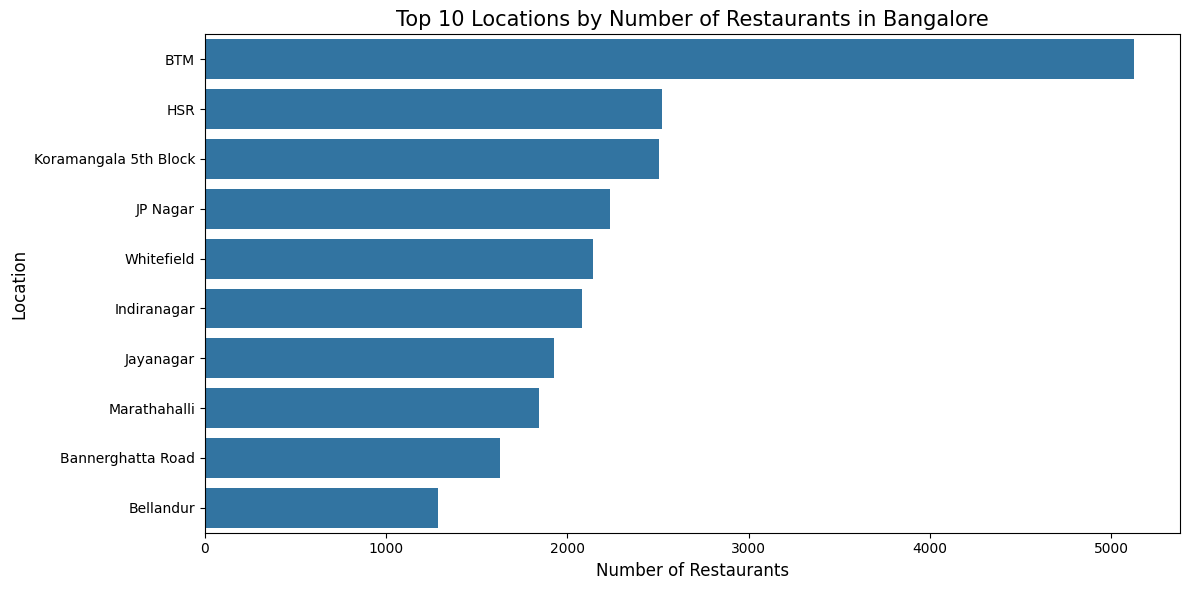

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['location'].value_counts().head(10).values, 
            y=df['location'].value_counts().head(10).index)
plt.title('Top 10 Locations by Number of Restaurants in Bangalore', fontsize=15)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.tight_layout()
plt.show()

## What does the overall rating distribution look like

In [32]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 26830 entries, 0 to 26829
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            26830 non-null  int64  
 1   rate             26830 non-null  float64
 2   rest_type        26830 non-null  str    
 3   cuisines         26830 non-null  str    
 4   cost_for_two     26830 non-null  int64  
 5   name             26830 non-null  str    
 6   online_order     26830 non-null  int64  
 7   book_table       26830 non-null  int64  
 8   votes            26830 non-null  int64  
 9   listed_in(type)  26830 non-null  str    
 10  location         26830 non-null  str    
dtypes: float64(1), int64(5), str(5)
memory usage: 2.3 MB


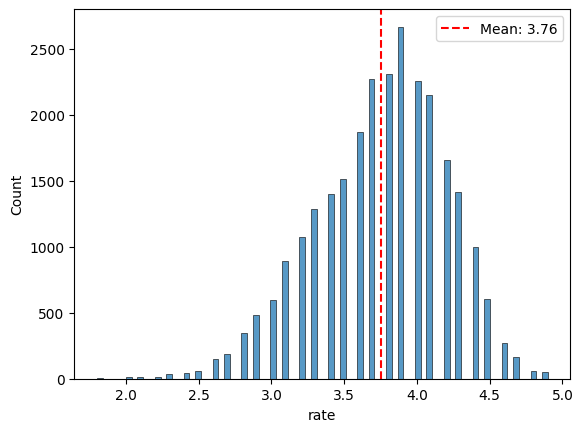

In [33]:
plt.plot()
plt.axvline(df3['rate'].mean(), color='red', linestyle='--', label=f"Mean: {df3['rate'].mean():.2f}")
plt.legend()
sns.histplot(df3["rate"])
plt.show()

## Q3 — Do restaurants that accept online orders have better ratings than those that don't?

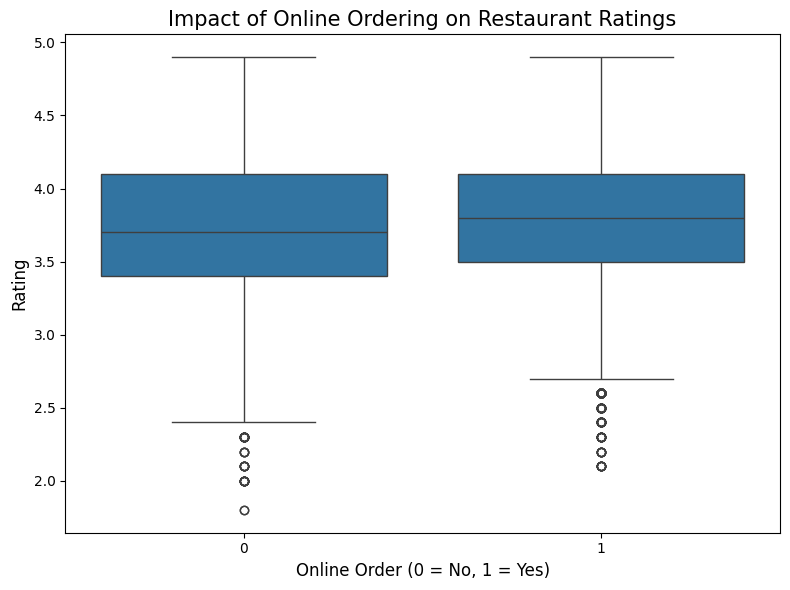

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='online_order', y='rate', data=df3)
plt.title('Impact of Online Ordering on Restaurant Ratings', fontsize=15)
plt.xlabel('Online Order (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.tight_layout()
plt.show()

## Q-4 Which restaurant type has the highest average rating

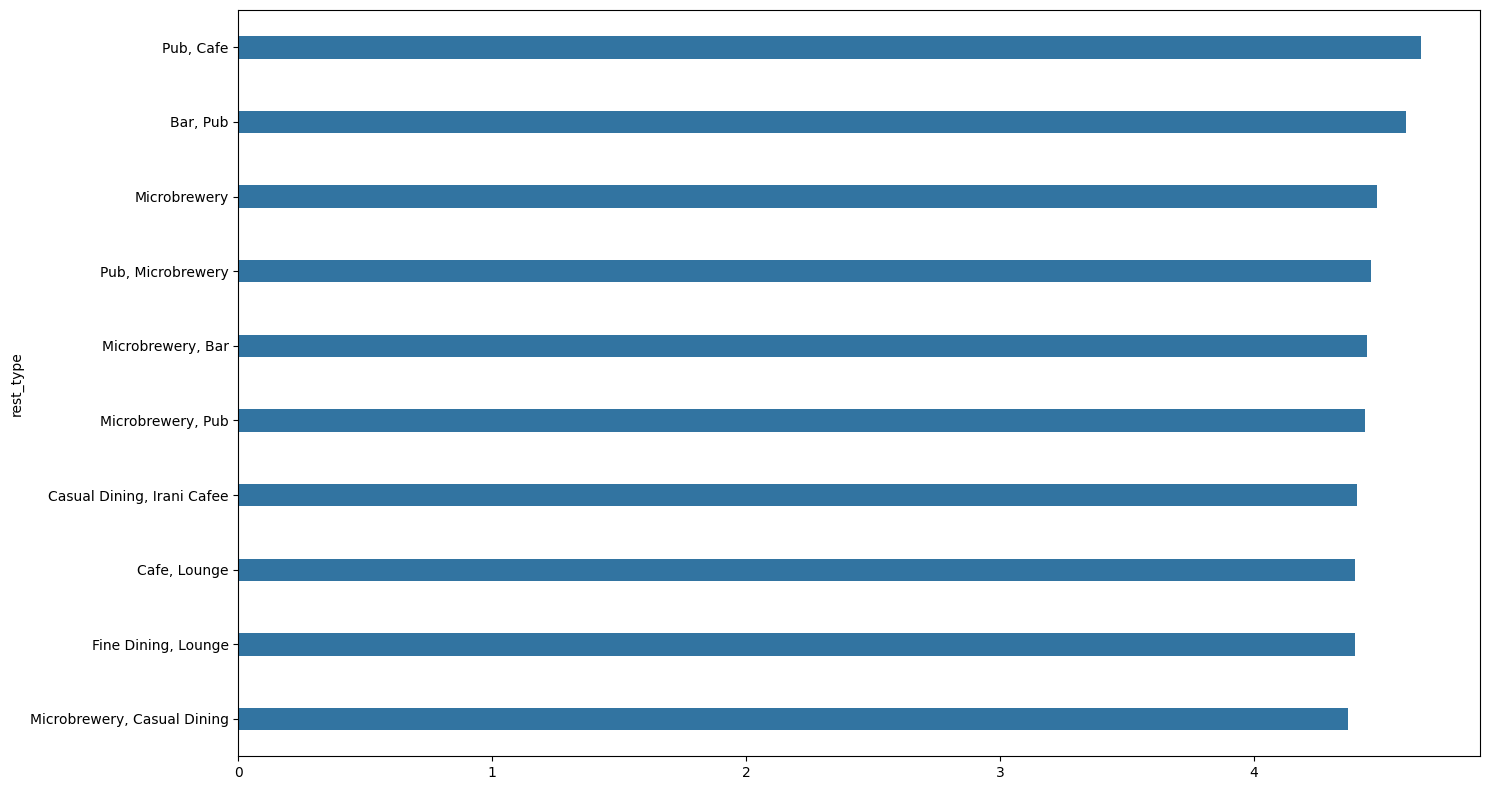

In [35]:
plt.figure(figsize=(15,8))

data = df3.groupby("rest_type")["rate"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=data.values, y=data.index, width=0.3)

plt.tight_layout()
plt.show()

In [36]:
df3.groupby("rest_type")["rate"].count().sort_values(ascending=False).head(10)

rest_type
Quick Bites           8409
Casual Dining         6589
Cafe                  2224
Dessert Parlor        1176
Casual Dining, Bar     900
Delivery               896
Takeaway, Delivery     721
Bakery                 449
Bar                    395
Bar, Casual Dining     326
Name: rate, dtype: int64

## Q-5 Which cuisines are most popular across Bangalore

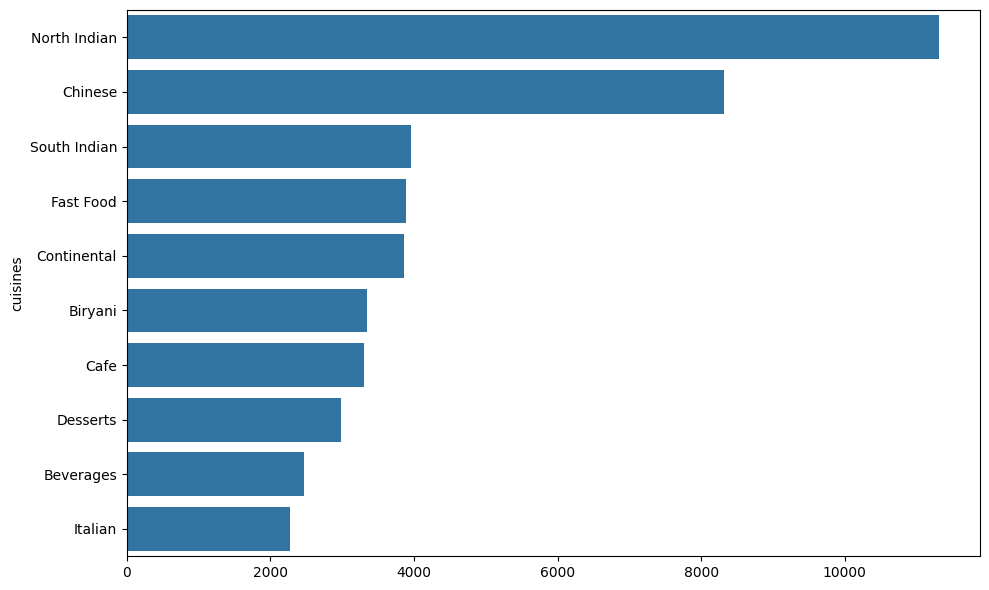

In [37]:
top_cuisines = df3['cuisines'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.tight_layout()
plt.show()

## Q6 — What is the most common price range — is Bangalore's food scene budget or premium?

In [38]:
pd.cut(df3["cost_for_two"],4)

0         (34.04, 1530.0]
1         (34.04, 1530.0]
2         (34.04, 1530.0]
3         (34.04, 1530.0]
4         (34.04, 1530.0]
               ...       
26825     (34.04, 1530.0]
26826     (34.04, 1530.0]
26827     (34.04, 1530.0]
26828    (1530.0, 3020.0]
26829     (34.04, 1530.0]
Name: cost_for_two, Length: 26830, dtype: category
Categories (4, interval[float64, right]): [(34.04, 1530.0] < (1530.0, 3020.0] < (3020.0, 4510.0] < (4510.0, 6000.0]]

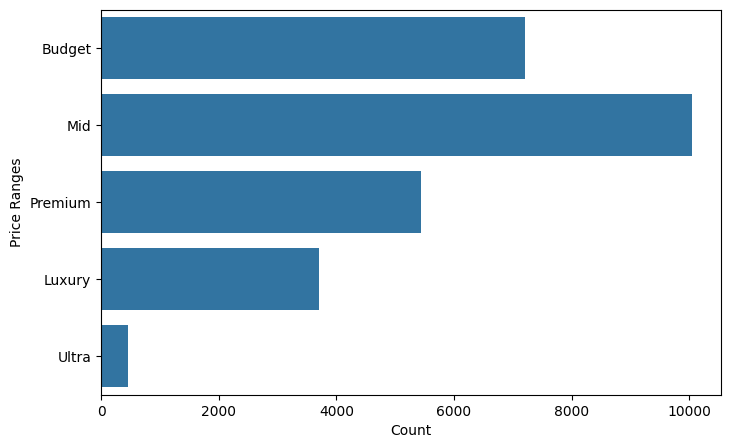

In [39]:
bins = [0, 300, 600, 1000, 2000, 6000]
labels = ['Budget', 'Mid', 'Premium', 'Luxury', 'Ultra']
df3['price_range'] = pd.cut(df3['cost_for_two'], bins=bins, labels=labels)
price_ranges = df3['price_range'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(y=price_ranges.index, x=price_ranges.values)
plt.ylabel("Price Ranges")
plt.xlabel("Count")
plt.show()

## Q-7 Does spending more money lead to a better restaurant

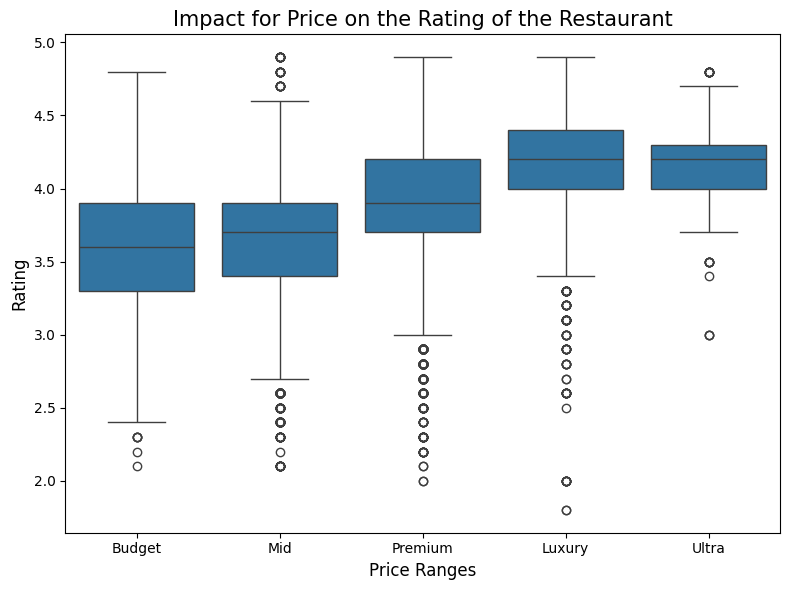

In [40]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='price_range', y='rate', data=df3)
plt.title('Impact for Price on the Rating of the Restaurant', fontsize=15)
plt.xlabel('Price Ranges', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.tight_layout()
plt.show()

## Key findings and recommendations

In [41]:
df3.head()

,index,rate,rest_type,cuisines,cost_for_two,name,online_order,book_table,votes,listed_in(type),location,price_range
0,0,4.1,Casual Dining,"North Indian, Mughlai, Chinese",800,Jalsa,1,1,775,Buffet,Banashankari,Premium
1,1,4.1,Casual Dining,"Chinese, North Indian, Thai",800,Spice Elephant,1,0,787,Buffet,Banashankari,Premium
2,2,3.8,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,San Churro Cafe,1,0,918,Buffet,Banashankari,Premium
3,3,3.7,Quick Bites,"South Indian, North Indian",300,Addhuri Udupi Bhojana,0,0,88,Buffet,Banashankari,Budget
4,4,3.8,Casual Dining,"North Indian, Rajasthani",600,Grand Village,0,0,166,Buffet,Basavanagudi,Mid


In [46]:
df3["cuisines"] = df3["cuisines"].str.strip().str.split(", ").str[0]

In [47]:
df3.head()

,index,rate,rest_type,cuisines,cost_for_two,name,online_order,book_table,votes,listed_in(type),location,price_range
0,0,4.1,Casual Dining,North Indian,800,Jalsa,1,1,775,Buffet,Banashankari,Premium
1,1,4.1,Casual Dining,Chinese,800,Spice Elephant,1,0,787,Buffet,Banashankari,Premium
2,2,3.8,"Cafe, Casual Dining",Cafe,800,San Churro Cafe,1,0,918,Buffet,Banashankari,Premium
3,3,3.7,Quick Bites,South Indian,300,Addhuri Udupi Bhojana,0,0,88,Buffet,Banashankari,Budget
4,4,3.8,Casual Dining,North Indian,600,Grand Village,0,0,166,Buffet,Basavanagudi,Mid


In [48]:
df3.to_csv("dataset/restaurants_cleaned.csv")